# Stage 01 - Parse ADAN-86 CellML with BG wall-thickness fix

This notebook parses the ADAN-86 CellML files into a solver-ready arterial tree.

**What is fixed vs the earlier NB01 parser**

The older parser used:

```python
h = 0.10 * r
```

That made `h/r` constant and collapsed wave speed into only a few discrete bands.  
This notebook reads the wall law from `BG_Modules_v2.cellml`:

```python
h = r * (a*exp(b*r) + c*exp(d*r))
```

For the uploaded BG module, the constants are:

```text
a = 0.2802
b = -505.3
c = 0.1324
d = -11.14
```

This gives radius-dependent wall thickness and much more realistic peripheral pulse-wave speed.

**Main output**

- `adan_parsed_bg.pkl` — solver-ready data dictionary
- `adan86_parsed_bg_from_cellml.csv` — parsed vessel table
- `adan86_edges_bg_from_cellml.csv` — parent→child topology
- `adan86_wall_speed_comparison.csv` — old constant-wall vs BG-wall comparison


## 1. Setup and input files



In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from __future__ import annotations
from pathlib import Path
from collections import defaultdict, deque

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

def find_input_file(candidates, glob_patterns=()):
    """
    Find an input file from exact paths or fallback glob patterns.

    Checks candidate paths first, then searches glob patterns and returns
    the most recently modified match when multiple files are found.

    Args:
        candidates: List of exact file paths to check.
        glob_patterns: Optional glob patterns used as fallback search.

    Returns:
        Path object for the found input file.

    Raises:
        FileNotFoundError: If no candidate or pattern match is found.
    """
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p

    for pattern in glob_patterns:
        hits = sorted(Path(".").glob(pattern))
        if hits:
            # Prefer most recently modified if there are multiple uploaded copies.
            hits = sorted(hits, key=lambda p: p.stat().st_mtime, reverse=True)
            return hits[0]

    raise FileNotFoundError(
        "Could not find any of these files/patterns:\n"
        f"Candidates: {candidates}\n"
        f"Patterns: {list(glob_patterns)}"
    )

MAIN_PATH = find_input_file(
    ["main_ADAN-86.cellml", "main_ADAN-86(3).cellml", "main_ADAN-86(2).cellml"],
    ["main_ADAN-86*.cellml"],
)

PARAMS_PATH = find_input_file(
    ["Parameters86.cellml", "Parameters86(3).cellml", "Parameters86(2).cellml"],
    ["Parameters86*.cellml"],
)

BG_PATH = find_input_file(
    ["BG_Modules_v2.cellml"],
    ["BG_Modules*.cellml"],
)

print("Using files:")
print(f"  main:   {MAIN_PATH.resolve()}")
print(f"  params: {PARAMS_PATH.resolve()}")
print(f"  BG:     {BG_PATH.resolve()}")


Using files:
  main:   D:\code\adan_project\main_ADAN-86.cellml
  params: D:\code\adan_project\Parameters86.cellml
  BG:     D:\code\adan_project\BG_Modules_v2.cellml


## 2. Reusable parser

This cell is intentionally self-contained.  
You can later move it into `adan86_parser_bg.py` if you prefer a module-based workflow.


In [ ]:
CELLML_NS = {"cellml": "http://www.cellml.org/cellml/1.1#"}
XLINK_HREF = "{http://www.w3.org/1999/xlink}href"


def _parse_float(x):
    """
    Safely convert a value to float.

    Args:
        x: Value to convert.

    Returns:
        Float value, or np.nan if conversion fails.
    """
    try:
        return float(x)
    except Exception:
        return np.nan


def _load_root(path):
    """
    Load an XML/CellML file and return its root element.

    Args:
        path: Path to the CellML file.

    Returns:
        XML root element.

    Raises:
        FileNotFoundError: If the file does not exist.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return ET.parse(path).getroot()


def _component_var_table(root):
    """
    Build a table of CellML components and their variables.

    Args:
        root: CellML XML root element.

    Returns:
        DataFrame with component names, variable lists, and variable counts.
    """
    rows = []
    for comp in root.findall("cellml:component", CELLML_NS):
        name = comp.attrib.get("name")
        variables = [
            var.attrib.get("name")
            for var in comp.findall("cellml:variable", CELLML_NS)
        ]
        rows.append(
            {
                "component": name,
                "variables": variables,
                "n_variables": len(variables),
            }
        )
    return pd.DataFrame(rows)


def _parse_connections(root):
    """
    Parse CellML connection blocks.

    Extracts connected components and their mapped variable pairs.

    Args:
        root: CellML XML root element.

    Returns:
        DataFrame describing CellML component connections.
    """
    rows = []
    for conn in root.findall("cellml:connection", CELLML_NS):
        mc = conn.find("cellml:map_components", CELLML_NS)
        if mc is None:
            continue

        c1 = mc.attrib.get("component_1")
        c2 = mc.attrib.get("component_2")

        variable_maps = []
        for mv in conn.findall("cellml:map_variables", CELLML_NS):
            variable_maps.append(
                (
                    mv.attrib.get("variable_1"),
                    mv.attrib.get("variable_2"),
                )
            )

        rows.append(
            {
                "component_1": c1,
                "component_2": c2,
                "variable_maps": variable_maps,
            }
        )

    return pd.DataFrame(rows)


def _parse_imported_bg_modules(main_root, bg_filename="BG_Modules_v2.cellml"):
    """
    Parse imported vessel module aliases from the main CellML file.

    Args:
        main_root: Main CellML XML root element.
        bg_filename: Name of the BG modules CellML file.

    Returns:
        DataFrame mapping module names to vessel names and module types.

    Raises:
        ValueError: If no modules are found or duplicates exist.
    """
    rows = []

    for imp in main_root.findall("cellml:import", CELLML_NS):
        href = imp.attrib.get(XLINK_HREF, "")
        if bg_filename not in href:
            continue

        for comp in imp.findall("cellml:component", CELLML_NS):
            module_name = comp.attrib.get("name")
            module_type = comp.attrib.get("component_ref")

            if module_name and module_name.endswith("_module"):
                rows.append(
                    {
                        "module": module_name,
                        "vessel": module_name.replace("_module", ""),
                        "module_type": module_type,
                        "import_href": href,
                    }
                )

    module_df = pd.DataFrame(rows)

    if module_df.empty:
        raise ValueError(
            "No vessel modules imported from BG_Modules_v2.cellml were found."
        )

    if module_df["vessel"].duplicated().any():
        dupes = module_df.loc[module_df["vessel"].duplicated(), "vessel"].tolist()
        raise ValueError(f"Duplicate imported vessel modules found: {dupes[:10]}")

    return module_df


def _infer_directed_module_edge(component_1, component_2, variable_maps):
    """
    Infer parent-to-child vessel direction from module connections.

    Args:
        component_1: First CellML component name.
        component_2: Second CellML component name.
        variable_maps: List of mapped variable pairs.

    Returns:
        (parent, child) vessel names, or None if direction cannot be inferred.
    """
    c1 = component_1
    c2 = component_2

    if not (
        isinstance(c1, str)
        and isinstance(c2, str)
        and c1.endswith("_module")
        and c2.endswith("_module")
    ):
        return None

    maps = set(variable_maps)

    # Normal ADAN direction: component_1 parent -> component_2 child.
    forward_v = ("v_out", "v") in maps or ("v_out_1", "v") in maps or ("v_out_2", "v") in maps
    forward_u = ("u", "u_in") in maps

    if forward_v and forward_u:
        return c1.replace("_module", ""), c2.replace("_module", "")

    # Reversed guard.
    reverse_v = ("v", "v_out") in maps or ("v", "v_out_1") in maps or ("v", "v_out_2") in maps
    reverse_u = ("u_in", "u") in maps

    if reverse_v and reverse_u:
        return c2.replace("_module", ""), c1.replace("_module", "")

    return None


def _parse_topology(conn_df):
    """
    Build vessel topology edges from parsed CellML connections.

    Args:
        conn_df: DataFrame of parsed CellML connections.

    Returns:
        DataFrame with parent-child vessel edges.

    Raises:
        ValueError: If no topology edges are found.
    """
    rows = []

    for _, row in conn_df.iterrows():
        edge = _infer_directed_module_edge(
            row["component_1"],
            row["component_2"],
            row["variable_maps"],
        )

        if edge is None:
            continue

        parent, child = edge
        rows.append(
            {
                "parent": parent,
                "child": child,
                "component_1": row["component_1"],
                "component_2": row["component_2"],
                "variable_maps": row["variable_maps"],
            }
        )

    topology_df = pd.DataFrame(rows)

    if topology_df.empty:
        raise ValueError("No module-module topology edges were found.")

    return topology_df


def _build_graph(vessels, topology_df):
    """
    Build vessel graph maps and traversal order.

    Args:
        vessels: Iterable of vessel names.
        topology_df: DataFrame with parent-child topology edges.

    Returns:
        (children_map, parent_map, root_vessel, order)

    Raises:
        ValueError: If graph is invalid, disconnected, cyclic, or has multiple roots.
    """
    children_map = defaultdict(list)
    parent_map = {}

    for _, row in topology_df.iterrows():
        parent = row["parent"]
        child = row["child"]

        children_map[parent].append(child)

        if child in parent_map:
            raise ValueError(
                f"Vessel {child} has multiple parents: "
                f"{parent_map[child]} and {parent}"
            )

        parent_map[child] = parent

    roots = sorted(set(vessels) - set(parent_map))

    if len(roots) != 1:
        raise ValueError(f"Expected exactly one root, found {len(roots)}: {roots}")

    root_vessel = roots[0]

    order = []
    seen = set()
    queue = deque([root_vessel])

    while queue:
        node = queue.popleft()

        if node in seen:
            raise ValueError(f"Cycle or duplicate traversal detected at {node}")

        seen.add(node)
        order.append(node)

        for child in children_map.get(node, []):
            queue.append(child)

    missing = sorted(set(vessels) - seen)
    if missing:
        raise ValueError(
            f"Topology does not reach {len(missing)} vessels from root. "
            f"First missing vessels: {missing[:10]}"
        )

    return dict(children_map), parent_map, root_vessel, order


def _parse_systemic_params(params_root):
    """
    Parse systemic parameter values from Parameters_Systemic.

    Args:
        params_root: Parameters CellML XML root element.

    Returns:
        DataFrame with parameter names, values, and units.

    Raises:
        ValueError: If Parameters_Systemic is missing.
    """
    comp = params_root.find(
        ".//cellml:component[@name='Parameters_Systemic']",
        CELLML_NS,
    )

    if comp is None:
        raise ValueError("Parameters_Systemic component not found.")

    rows = []

    for var in comp.findall("cellml:variable", CELLML_NS):
        rows.append(
            {
                "param_name": var.attrib.get("name"),
                "value": _parse_float(var.attrib.get("initial_value")),
                "units": var.attrib.get("units"),
            }
        )

    return pd.DataFrame(rows)


def _parse_vessel_parameter_maps(conn_df, param_values, default_g=9.81):
    """
    Map systemic parameters onto vessel modules.

    Args:
        conn_df: DataFrame of parsed CellML connections.
        param_values: Dictionary of parameter names to values.
        default_g: Default gravity value if missing.

    Returns:
        DataFrame with vessel geometry, material, and terminal parameters.
    """
    wanted = {"l", "E", "r_p", "r_d", "theta", "g", "R_T", "C_T"}
    rows = []

    for _, row in conn_df.iterrows():
        c1 = row["component_1"]
        c2 = row["component_2"]

        if c1 != "Parameters_Systemic":
            continue

        if not (isinstance(c2, str) and c2.endswith("_module")):
            continue

        item = {"vessel": c2.replace("_module", "")}

        for param_name, module_var in row["variable_maps"]:
            if module_var not in wanted:
                continue

            value = param_values.get(param_name, np.nan)

            if module_var == "g" and not np.isfinite(value):
                value = default_g

            item[module_var] = value
            item[f"{module_var}_param"] = param_name

        rows.append(item)

    df = pd.DataFrame(rows)

    rename = {
        "l": "length_m",
        "E": "E_Pa",
        "r_p": "r_proximal_m",
        "r_d": "r_distal_m",
        "theta": "theta_deg",
        "g": "g_m_per_s2",
        "R_T": "R_T_Js_per_m6",
        "C_T": "C_T_m6_per_J",
    }

    return df.rename(columns=rename)


def _parse_cellml_terminals_and_root_inlet(conn_df):
    """
    Detect terminal vessels and root inlet vessel from CellML mappings.

    Args:
        conn_df: DataFrame of parsed CellML connections.

    Returns:
        (terminal_vessels, root_inlet_vessel)
    """
    terminal_vessels = []
    root_inlet_vessel = None

    for _, row in conn_df.iterrows():
        c1 = row["component_1"]
        c2 = row["component_2"]
        maps = set(row["variable_maps"])

        # Normal ADAN convention: Systemic is component_1.
        if c1 == "Systemic" and isinstance(c2, str) and c2.endswith("_module"):
            vessel = c2.replace("_module", "")

            if any(v2 == "v_T" for _, v2 in row["variable_maps"]):
                terminal_vessels.append(vessel)

            if ("v_aov", "v_in") in maps:
                root_inlet_vessel = vessel

        # Reversed guard.
        elif c2 == "Systemic" and isinstance(c1, str) and c1.endswith("_module"):
            vessel = c1.replace("_module", "")

            if any(v1 == "v_T" for v1, _ in row["variable_maps"]):
                terminal_vessels.append(vessel)

            if ("v_in", "v_aov") in maps:
                root_inlet_vessel = vessel

    return sorted(set(terminal_vessels)), root_inlet_vessel


def _parse_bg_wall_constants(bg_root):
    """
    Parse wall thickness constants from BG modules.

    Args:
        bg_root: BG modules CellML XML root element.

    Returns:
        (wall_constants, const_df)
        Dictionary with a, b, c, d constants and full constants DataFrame.

    Raises:
        ValueError: If constants are missing, invalid, or inconsistent.
    """
    rows = []

    for comp in bg_root.findall("cellml:component", CELLML_NS):
        module_type = comp.attrib.get("name")
        vals = {}

        for var in comp.findall("cellml:variable", CELLML_NS):
            name = var.attrib.get("name")

            if name in {"a", "b", "c", "d"}:
                vals[name] = _parse_float(var.attrib.get("initial_value"))

        if vals:
            rows.append({"module_type": module_type, **vals})

    const_df = pd.DataFrame(rows)

    if const_df.empty:
        raise ValueError("Could not find BG wall constants a,b,c,d.")

    if const_df[["a", "b", "c", "d"]].isna().any().any():
        raise ValueError("Some BG wall constants are missing/non-numeric.")

    unique = const_df[["a", "b", "c", "d"]].drop_duplicates()

    if len(unique) != 1:
        raise ValueError(
            "Different BG module types use different wall constants:\n"
            f"{unique}"
        )

    return unique.iloc[0].to_dict(), const_df


def _compute_bg_lumped_values(r_proximal, r_distal, radius_mean, length, E, h, rho, mu):
    """
    Compute BG lumped vessel values from geometry and material parameters.

    Args:
        r_proximal: Proximal vessel radius.
        r_distal: Distal vessel radius.
        radius_mean: Mean vessel radius.
        length: Vessel length.
        E: Young's modulus.
        h: Wall thickness.
        rho: Blood density.
        mu: Dynamic viscosity.

    Returns:
        (q0, I, C, R, R_v) lumped vessel values.
    """
    rp = r_proximal
    rd = r_distal
    r = radius_mean
    l = length

    q0 = np.pi * l / 3.0 * (rp**2 + rd * rp + rd**2)

    I = rho * l / (np.pi * r**2)

    C = 2.0 * np.pi * r**3 * l / (E * h)

    R = (
        8.0
        * mu
        * l
        / (3.0 * np.pi)
        * (
            1.0 / (rp**3 * rd)
            + 1.0 / (rp**2 * rd**2)
            + 1.0 / (rp * rd**3)
        )
    )

    R_v = 0.01 / C

    return q0, I, C, R, R_v


def parse_adan_cellml(
    main_path,
    params_path,
    bg_modules_path,
    *,
    rho=1060.0,
    mu=0.004,
    dx_target=0.005,
    cfl_target=0.4,
    use_solver_consistent_c0=True,
):
    """
    Parse ADAN CellML files into solver-ready data.

    Builds vessel topology, physical vessel parameters, wall properties,
    numerical grid arrays, terminal/root indices, and validation diagnostics.

    Args:
        main_path: Path to main ADAN CellML file.
        params_path: Path to Parameters CellML file.
        bg_modules_path: Path to BG modules CellML file.
        rho: Blood density.
        mu: Dynamic blood viscosity.
        dx_target: Target spatial grid size.
        cfl_target: Target CFL value.
        use_solver_consistent_c0: Whether to use wave speed consistent
            with the solver pressure-area law.

    Returns:
        Dictionary containing DataFrames, solver arrays, graph data,
        constants, and diagnostics.

    Raises:
        ValueError: If parsing or validation fails.
    """
    main_root = _load_root(main_path)
    params_root = _load_root(params_path)
    bg_root = _load_root(bg_modules_path)

    conn_df = _parse_connections(main_root)
    module_df = _parse_imported_bg_modules(main_root)

    comp_df = _component_var_table(main_root)
    required_vessel_vars = {"u", "v", "E", "r_p", "r_d", "h", "l", "q_0"}

    vessel_df = comp_df[
        comp_df["variables"].apply(lambda xs: required_vessel_vars.issubset(set(xs)))
    ].copy()

    vessels = sorted(set(vessel_df["component"]))

    if not vessels:
        raise ValueError("No concrete vessel components found in main CellML.")

    topology_df = _parse_topology(conn_df)
    children_map, parent_map, root_vessel, order = _build_graph(vessels, topology_df)

    terminal_vessels, root_inlet_vessel = _parse_cellml_terminals_and_root_inlet(conn_df)

    node_df = pd.DataFrame({"vessel": order})
    node_df["order_index"] = np.arange(len(order))
    node_df["parent"] = node_df["vessel"].map(parent_map)
    node_df["children"] = node_df["vessel"].map(lambda x: children_map.get(x, []))
    node_df["n_children"] = node_df["children"].apply(len)
    node_df["is_root"] = node_df["parent"].isna()
    node_df["is_topological_terminal"] = node_df["n_children"].eq(0)
    node_df["is_cellml_terminal"] = node_df["vessel"].isin(terminal_vessels)

    params_df = _parse_systemic_params(params_root)
    param_values = params_df.set_index("param_name")["value"].to_dict()
    vessel_params_df = _parse_vessel_parameter_maps(conn_df, param_values)

    wall_constants, bg_const_df = _parse_bg_wall_constants(bg_root)

    node_full_df = (
        node_df
        .merge(module_df[["vessel", "module", "module_type"]], on="vessel", how="left")
        .merge(vessel_params_df, on="vessel", how="left")
    )

    # Physical arrays.
    Lv = node_full_df["length_m"].to_numpy(dtype=float)
    Ev = node_full_df["E_Pa"].to_numpy(dtype=float)
    r_proximal_v = node_full_df["r_proximal_m"].to_numpy(dtype=float)
    r_distal_v = node_full_df["r_distal_m"].to_numpy(dtype=float)
    rv = 0.5 * (r_proximal_v + r_distal_v)

    A0_proximal_v = np.pi * r_proximal_v**2
    A0_distal_v = np.pi * r_distal_v**2

    # Keep mean-of-areas for solver compatibility with your old parser.
    A0v = 0.5 * (A0_proximal_v + A0_distal_v)

    # Also store pi*(mean radius)^2 because A0v != pi*rv^2 for tapered vessels.
    A0_from_rv = np.pi * rv**2
    A0_relerr = A0v / A0_from_rv - 1.0

    a = wall_constants["a"]
    b = wall_constants["b"]
    c = wall_constants["c"]
    d = wall_constants["d"]

    h_over_r_v = a * np.exp(b * rv) + c * np.exp(d * rv)
    hv = rv * h_over_r_v

    # Coefficient used by your solver pressure-area law:
    #     P = betav * (sqrt(A) - sqrt(A0))
    # This is beta/A0 in common notation, not beta alone.
    betav = (4.0 / 3.0) * np.sqrt(np.pi) * Ev * hv / A0v

    # Two speed definitions:
    # 1) Diagnostic Moens-Korteweg from E,h,r.
    c0_mk_v = np.sqrt(Ev * hv / (2.0 * rho * rv))

    # 2) Speed consistent with the solver's P(A) law above.
    c0_solver_v = np.sqrt(betav * np.sqrt(A0v) / (2.0 * rho))

    c0v = c0_solver_v if use_solver_consistent_c0 else c0_mk_v

    Z0v = rho * c0v / A0v

    q0_bg_v, I_bg_v, C_bg_v, R_bg_v, Rv_bg_v = _compute_bg_lumped_values(
        r_proximal_v,
        r_distal_v,
        rv,
        Lv,
        Ev,
        hv,
        rho,
        mu,
    )

    # Numerical grid.
    Nv = np.maximum(3, np.ceil(Lv / dx_target).astype(int) + 1)
    dxv = Lv / (Nv - 1)

    dt_global = cfl_target * np.min(dxv / c0v)
    cfl_actual = c0v * dt_global / dxv

    vessel_to_idx = {vessel: i for i, vessel in enumerate(order)}

    node_full_df["idx"] = node_full_df["vessel"].map(vessel_to_idx).astype(int)
    node_full_df["parent_idx"] = (
        node_full_df["parent"].map(vessel_to_idx).fillna(-1).astype(int)
    )
    node_full_df["children_idx"] = node_full_df["children"].apply(
        lambda xs: [vessel_to_idx[x] for x in xs]
    )

    children_idx = node_full_df["children_idx"].tolist()
    children_map_idx = {
        vessel_to_idx[parent]: [vessel_to_idx[ch] for ch in children]
        for parent, children in children_map.items()
    }

    terminal_idx = np.array(
        [i for i, children in enumerate(children_idx) if len(children) == 0],
        dtype=int,
    )
    cellml_terminal_idx = np.array(
        [vessel_to_idx[v] for v in terminal_vessels],
        dtype=int,
    )
    root_idx = np.array([vessel_to_idx[root_vessel]], dtype=int)

    # Attach derived columns.
    node_full_df["A0_proximal_m2"] = A0_proximal_v
    node_full_df["A0_distal_m2"] = A0_distal_v
    node_full_df["A0_mean_m2"] = A0v
    node_full_df["A0_from_radius_mean_m2"] = A0_from_rv
    node_full_df["A0_mean_vs_pi_rmean2_relerr"] = A0_relerr
    node_full_df["radius_mean_m"] = rv
    node_full_df["h_over_r_bg"] = h_over_r_v
    node_full_df["h_m"] = hv
    node_full_df["beta_per_A0_Pa_per_m"] = betav
    node_full_df["c0_mk_m_per_s"] = c0_mk_v
    node_full_df["c0_solver_m_per_s"] = c0_solver_v
    node_full_df["c0_used_m_per_s"] = c0v
    node_full_df["Z0_Pa_s_per_m3"] = Z0v
    node_full_df["q0_bg_m3"] = q0_bg_v
    node_full_df["I_bg_Js2_per_m6"] = I_bg_v
    node_full_df["C_bg_m6_per_J"] = C_bg_v
    node_full_df["R_bg_Js_per_m6"] = R_bg_v
    node_full_df["Rv_bg_Js_per_m6"] = Rv_bg_v
    node_full_df["Nv"] = Nv
    node_full_df["dx_m"] = dxv
    node_full_df["CFL_at_dt_global"] = cfl_actual

    diagnostics = {
        "n_vessels": int(len(order)),
        "n_edges": int(len(topology_df)),
        "n_terminals_topology": int(len(terminal_idx)),
        "n_terminals_cellml_v_T": int(len(cellml_terminal_idx)),
        "root_vessel": root_vessel,
        "root_inlet_vessel": root_inlet_vessel,
        "wall_model": "BG_Modules_v2: h = r*(a*exp(b*r)+c*exp(d*r))",
        "wall_constants": {k: float(v) for k, v in wall_constants.items()},
        "h_over_r_range": (
            float(np.min(h_over_r_v)),
            float(np.max(h_over_r_v)),
        ),
        "h_over_r_median": float(np.median(h_over_r_v)),
        "c0_used_range_m_per_s": (
            float(np.min(c0v)),
            float(np.max(c0v)),
        ),
        "c0_mk_range_m_per_s": (
            float(np.min(c0_mk_v)),
            float(np.max(c0_mk_v)),
        ),
        "c0_solver_range_m_per_s": (
            float(np.min(c0_solver_v)),
            float(np.max(c0_solver_v)),
        ),
        "unique_c0_used_rounded_3dp": int(len(np.unique(np.round(c0v, 3)))),
        "dt_global_s": float(dt_global),
        "max_cfl": float(np.max(cfl_actual)),
        "module_type_counts": {
            str(k): int(v)
            for k, v in node_full_df["module_type"].value_counts().to_dict().items()
        },
        "E_Pa_counts": {
            float(k): int(v)
            for k, v in node_full_df["E_Pa"].value_counts().sort_index().to_dict().items()
        },
        "max_A0_mean_vs_pi_rmean2_relerr_abs": float(np.max(np.abs(A0_relerr))),
    }

    # Strong validation.
    errors = []

    if len(topology_df) != len(order) - 1:
        errors.append(
            f"Topology edge count mismatch: {len(topology_df)} != {len(order)-1}"
        )

    if len(root_idx) != 1:
        errors.append(f"Expected one root, found {len(root_idx)}")

    if root_inlet_vessel is not None and root_inlet_vessel != root_vessel:
        errors.append(
            f"Root inlet vessel {root_inlet_vessel} != topological root {root_vessel}"
        )

    if not np.array_equal(np.sort(terminal_idx), np.sort(cellml_terminal_idx)):
        topo_terms = set(node_full_df.loc[terminal_idx, "vessel"])
        cellml_terms = set(terminal_vessels)
        errors.append(
            "Topological terminals differ from CellML v_T terminals. "
            f"Only topology: {sorted(topo_terms - cellml_terms)[:10]}, "
            f"only CellML: {sorted(cellml_terms - topo_terms)[:10]}"
        )

    required_cols = [
        "length_m",
        "E_Pa",
        "r_proximal_m",
        "r_distal_m",
        "theta_deg",
        "h_m",
        "A0_mean_m2",
        "beta_per_A0_Pa_per_m",
        "c0_used_m_per_s",
    ]

    nan_counts = node_full_df[required_cols].isna().sum()
    bad_nan = nan_counts[nan_counts > 0]

    if len(bad_nan):
        errors.append(f"Missing required values: {bad_nan.to_dict()}")

    positive_cols = [
        "length_m",
        "E_Pa",
        "r_proximal_m",
        "r_distal_m",
        "h_m",
        "A0_mean_m2",
        "beta_per_A0_Pa_per_m",
        "c0_used_m_per_s",
        "dx_m",
    ]

    for col in positive_cols:
        arr = node_full_df[col].to_numpy(dtype=float)
        if not np.all(np.isfinite(arr)):
            errors.append(f"{col} contains non-finite values")
        if not np.all(arr > 0):
            errors.append(f"{col} contains non-positive values")

    if not np.all(cfl_actual <= cfl_target + 1e-12):
        errors.append("CFL actual exceeds target")

    if errors:
        raise ValueError("ADAN parser validation failed:\n- " + "\n- ".join(errors))

    adan_data = {
        # DataFrames.
        "node_full_df": node_full_df.copy(),
        "topology_df": topology_df.copy(),
        "module_df": module_df.copy(),
        "params_df": params_df.copy(),
        "bg_wall_constants_df": bg_const_df.copy(),

        # Order / indexing.
        "order": order.copy(),
        "vessel_to_idx": vessel_to_idx.copy(),

        # Solver arrays.
        "A0v": A0v.astype(float),
        "Lv": Lv.astype(float),
        "rv": rv.astype(float),
        "r_proximal_v": r_proximal_v.astype(float),
        "r_distal_v": r_distal_v.astype(float),
        "hv": hv.astype(float),
        "h_over_r_v": h_over_r_v.astype(float),
        "Ev": Ev.astype(float),
        "betav": betav.astype(float),
        "c0v": c0v.astype(float),
        "c0_mk_v": c0_mk_v.astype(float),
        "c0_solver_v": c0_solver_v.astype(float),
        "Z0v": Z0v.astype(float),

        # BG lumped diagnostic arrays.
        "q0_bg_v": q0_bg_v.astype(float),
        "I_bg_v": I_bg_v.astype(float),
        "C_bg_v": C_bg_v.astype(float),
        "R_bg_v": R_bg_v.astype(float),
        "Rv_bg_v": Rv_bg_v.astype(float),

        # Numerical grid.
        "dxv": dxv.astype(float),
        "Nv": Nv.astype(int),
        "dt_global": float(dt_global),

        # Graph/index arrays.
        "parent_idx": node_full_df["parent_idx"].to_numpy(dtype=int),
        "children_idx": [list(map(int, x)) for x in children_idx],
        "children_map_idx": {
            int(k): [int(c) for c in v]
            for k, v in children_map_idx.items()
        },
        "terminal_idx": terminal_idx.copy(),
        "cellml_terminal_idx": cellml_terminal_idx.copy(),
        "root_idx": root_idx.copy(),

        # Constants.
        "RHO": float(rho),
        "MU": float(mu),
        "MMHG": 133.322,
        "DX_TARGET": float(dx_target),
        "CFL_TARGET": float(cfl_target),
        "wall_model": "bg_modules_v2",
        "wall_constants": {k: float(v) for k, v in wall_constants.items()},

        # Checks / summary.
        "diagnostics": diagnostics,
    }

    return adan_data


def print_adan_diagnostics(data):
    """
    Print the main ADAN parser diagnostics.

    Args:
        data: Parsed ADAN data dictionary.

    Returns:
        None.
    """
    d = data["diagnostics"]

    print("ADAN parser diagnostics")
    print("-" * 60)
    print(f"Vessels:              {d['n_vessels']}")
    print(f"Topology edges:       {d['n_edges']}")
    print(f"Terminals topology:   {d['n_terminals_topology']}")
    print(f"Terminals CellML v_T: {d['n_terminals_cellml_v_T']}")
    print(f"Root vessel:          {d['root_vessel']}")
    print(f"Root inlet vessel:    {d['root_inlet_vessel']}")
    print()
    print(f"Wall model:           {d['wall_model']}")
    print(f"Wall constants:       {d['wall_constants']}")
    print(f"h/r range:            {d['h_over_r_range'][0]:.4f} - {d['h_over_r_range'][1]:.4f}")
    print(f"h/r median:           {d['h_over_r_median']:.4f}")
    print()
    print(f"c0 used range:        {d['c0_used_range_m_per_s'][0]:.3f} - {d['c0_used_range_m_per_s'][1]:.3f} m/s")
    print(f"c0 MK range:          {d['c0_mk_range_m_per_s'][0]:.3f} - {d['c0_mk_range_m_per_s'][1]:.3f} m/s")
    print(f"c0 solver range:      {d['c0_solver_range_m_per_s'][0]:.3f} - {d['c0_solver_range_m_per_s'][1]:.3f} m/s")
    print(f"Unique rounded c0:    {d['unique_c0_used_rounded_3dp']}")
    print()
    print(f"dt_global:            {d['dt_global_s']:.8e} s")
    print(f"max CFL:              {d['max_cfl']:.3f}")
    print()
    print(f"Module types:         {d['module_type_counts']}")
    print(f"E bands:              {d['E_Pa_counts']}")


def save_adan_pickle(data, output_path="adan_parsed_bg.pkl"):
    """
    Save parsed ADAN data to a pickle file.

    Args:
        data: Parsed ADAN data dictionary.
        output_path: Output pickle file path.

    Returns:
        None.
    """
    output_path = Path(output_path)

    with output_path.open("wb") as f:
        pickle.dump(data, f)

    print(f"Saved: {output_path.resolve()}")
    print(f"File size MB: {output_path.stat().st_size / 1024 / 1024:.3f}")


def load_adan_pickle(path="adan_parsed_bg.pkl"):
    """
    Load parsed ADAN data from a pickle file.

    Args:
        path: Path to pickle file.

    Returns:
        Parsed ADAN data dictionary.
    """
    with Path(path).open("rb") as f:
        return pickle.load(f)

## 3. Parse ADAN-86 and print diagnostics

This is the main parser call.  
By default it uses the solver-consistent wave speed from the pressure-area law:

```python
P = betav * (sqrt(A) - sqrt(A0))
c0 = sqrt(betav * sqrt(A0) / (2*rho))
```

The notebook also stores the Moens-Korteweg diagnostic speed separately as `c0_mk_v`.


In [3]:

adan_data = parse_adan_cellml(
    MAIN_PATH,
    PARAMS_PATH,
    BG_PATH,
    rho=1060.0,
    mu=0.004,
    dx_target=0.005,
    cfl_target=0.4,
    use_solver_consistent_c0=True,
)

print_adan_diagnostics(adan_data)


ADAN parser diagnostics
------------------------------------------------------------
Vessels:              103
Topology edges:       102
Terminals topology:   43
Terminals CellML v_T: 43
Root vessel:          ascending_aorta_C0
Root inlet vessel:    ascending_aorta_C0

Wall model:           BG_Modules_v2: h = r*(a*exp(b*r)+c*exp(d*r))
Wall constants:       {'a': 0.2802, 'b': -505.3, 'c': 0.1324, 'd': -11.14}
h/r range:            0.1125 - 0.3429
h/r median:           0.2183

c0 used range:        4.542 - 18.238 m/s
c0 MK range:          3.955 - 15.794 m/s
c0 solver range:      4.542 - 18.238 m/s
Unique rounded c0:    68

dt_global:            7.47174338e-05 s
max CFL:              0.400

Module types:         {'pp_BC_type': 43, 'pv_jII_type': 42, 'pv_type': 17, 'vv_type': 1}
E bands:              {200000.0: 2, 400000.0: 65, 800000.0: 20, 1600000.0: 16}


## 4. Inspect parsed vessels and topology

The most important checks are:

- exactly one root
- 102 parent→child edges for 103 vessels
- topological terminals match CellML `v_T` terminals
- no missing or non-positive geometry/stiffness/speed values


In [4]:

node_full_df = adan_data["node_full_df"]
topology_df = adan_data["topology_df"]

display_cols = [
    "idx",
    "vessel",
    "parent",
    "n_children",
    "is_root",
    "is_topological_terminal",
    "is_cellml_terminal",
    "module_type",
    "length_m",
    "radius_mean_m",
    "h_over_r_bg",
    "h_m",
    "E_Pa",
    "A0_mean_m2",
    "beta_per_A0_Pa_per_m",
    "c0_used_m_per_s",
    "c0_mk_m_per_s",
    "Nv",
    "dx_m",
    "CFL_at_dt_global",
]

display(node_full_df[display_cols].head(20))
display(topology_df[["parent", "child"]].head(20))


,idx,vessel,parent,n_children,is_root,is_topological_terminal,is_cellml_terminal,module_type,length_m,radius_mean_m,h_over_r_bg,h_m,E_Pa,A0_mean_m2,beta_per_A0_Pa_per_m,c0_used_m_per_s,c0_mk_m_per_s,Nv,dx_m,CFL_at_dt_global
0,0,ascending_aorta_C0,NaN,1,True,False,False,vv_type,0.060000,0.014788,0.112450,0.001663,400000.0,0.000691,2.274080e+06,5.310590,4.606191,13,0.005000,0.079359
1,1,aortic_arch_C2,ascending_aorta_C0,2,False,False,False,pv_jII_type,0.014476,0.013290,0.114519,0.001522,400000.0,0.000555,2.591153e+06,5.366632,4.648379,4,0.004825,0.083101
2,2,brachiocephalic_trunk_C4,aortic_arch_C2,2,False,False,False,pv_jII_type,0.047382,0.006443,0.134031,0.000864,400000.0,0.000131,6.246899e+06,5.803922,5.028795,11,0.004738,0.091523
3,3,aortic_arch_C46,aortic_arch_C2,2,False,False,False,pv_jII_type,0.009608,0.012762,0.115298,0.001471,400000.0,0.000512,2.717916e+06,5.385384,4.664147,3,0.004804,0.083756
4,4,common_carotid_R6,brachiocephalic_trunk_C4,2,False,False,False,pv_jII_type,0.081253,0.003901,0.165801,0.000647,200000.0,0.000049,6.258792e+06,4.542335,3.954949,18,0.004780,0.071008
5,5,subclavian_R28,brachiocephalic_trunk_C4,2,False,False,False,pv_jII_type,0.015747,0.004537,0.154185,0.000699,400000.0,0.000065,1.016315e+07,6.218330,5.393648,5,0.003937,0.118021
6,6,aortic_arch_C64,aortic_arch_C46,2,False,False,False,pv_jII_type,0.006980,0.012428,0.115807,0.001439,400000.0,0.000485,2.803465e+06,5.397395,4.674430,3,0.003490,0.115560
7,7,common_carotid_L48,aortic_arch_C46,2,False,False,False,pv_jII_type,0.121356,0.003901,0.165801,0.000647,200000.0,0.000049,6.258792e+06,4.542335,3.954949,26,0.004854,0.069917
8,8,internal_carotid_R8,common_carotid_R6,0,False,True,True,pp_BC_type,0.135108,0.002052,0.228750,0.000469,1600000.0,0.000015,1.197051e+08,14.745480,13.139319,29,0.004825,0.228327
9,9,external_carotid_T2_R26,common_carotid_R6,0,False,True,True,pp_BC_type,0.061012,0.002265,0.218290,0.000495,800000.0,0.000016,5.798675e+07,10.480044,9.075984,14,0.004693,0.166844


,parent,child
0,aortic_arch_C2,brachiocephalic_trunk_C4
1,aortic_arch_C2,aortic_arch_C46
2,brachiocephalic_trunk_C4,common_carotid_R6
3,brachiocephalic_trunk_C4,subclavian_R28
4,aortic_arch_C46,aortic_arch_C64
5,aortic_arch_C46,common_carotid_L48
6,aortic_arch_C64,aortic_arch_C94
7,aortic_arch_C64,subclavian_L66
8,thoracic_aorta_C96,thoracic_aorta_C100
9,thoracic_aorta_C96,posterior_intercostal_T1_R98


## 5. Compare old constant wall model vs BG wall model

This is the key verification cell.

The old approximation used:

```python
h_old = 0.10 * r
```

The fixed BG model uses:

```python
h_bg = r * (a*exp(b*r) + c*exp(d*r))
```

Expected outcome: old model has only a few speed bands, while the BG model has many more radius-dependent speeds.


In [5]:

RHO = adan_data["RHO"]

rv = adan_data["rv"]
A0v = adan_data["A0v"]
Ev = adan_data["Ev"]

# Old fallback model.
hv_const = 0.10 * rv
betav_const = (4.0 / 3.0) * np.sqrt(np.pi) * Ev * hv_const / A0v
c0_const_solver = np.sqrt(betav_const * np.sqrt(A0v) / (2.0 * RHO))
c0_const_mk = np.sqrt(Ev * hv_const / (2.0 * RHO * rv))

# New BG model.
hv_bg = adan_data["hv"]
h_over_r_bg = adan_data["h_over_r_v"]
c0_bg_solver = adan_data["c0_solver_v"]
c0_bg_mk = adan_data["c0_mk_v"]

comparison_df = node_full_df[[
    "idx",
    "vessel",
    "module_type",
    "radius_mean_m",
    "E_Pa",
    "h_over_r_bg",
    "h_m",
    "c0_solver_m_per_s",
    "c0_mk_m_per_s",
]].copy()

comparison_df["h_const_m"] = hv_const
comparison_df["h_const_over_r"] = 0.10
comparison_df["c0_const_solver_m_per_s"] = c0_const_solver
comparison_df["c0_const_mk_m_per_s"] = c0_const_mk
comparison_df["solver_speed_gain_bg_vs_const"] = c0_bg_solver / c0_const_solver
comparison_df["mk_speed_gain_bg_vs_const"] = c0_bg_mk / c0_const_mk

summary = pd.DataFrame({
    "metric": [
        "h/r min",
        "h/r median",
        "h/r max",
        "c0 solver min",
        "c0 solver median",
        "c0 solver max",
        "unique rounded c0 solver, 3 dp",
        "unique rounded c0 MK, 3 dp",
    ],
    "old_constant_h_over_r_0p10": [
        0.10,
        0.10,
        0.10,
        float(np.min(c0_const_solver)),
        float(np.median(c0_const_solver)),
        float(np.max(c0_const_solver)),
        int(len(np.unique(np.round(c0_const_solver, 3)))),
        int(len(np.unique(np.round(c0_const_mk, 3)))),
    ],
    "new_BG_Modules_v2": [
        float(np.min(h_over_r_bg)),
        float(np.median(h_over_r_bg)),
        float(np.max(h_over_r_bg)),
        float(np.min(c0_bg_solver)),
        float(np.median(c0_bg_solver)),
        float(np.max(c0_bg_solver)),
        int(len(np.unique(np.round(c0_bg_solver, 3)))),
        int(len(np.unique(np.round(c0_bg_mk, 3)))),
    ],
})

display(summary)

print("Top 10 vessels with largest BG speed increase vs constant h/r=0.10:")
display(
    comparison_df
    .sort_values("solver_speed_gain_bg_vs_const", ascending=False)
    .head(10)
    [[
        "idx",
        "vessel",
        "radius_mean_m",
        "E_Pa",
        "h_const_over_r",
        "h_over_r_bg",
        "c0_const_solver_m_per_s",
        "c0_solver_m_per_s",
        "solver_speed_gain_bg_vs_const",
    ]]
)


,metric,old_constant_h_over_r_0p10,new_BG_Modules_v2
0,h/r min,0.100000,0.112450
1,h/r median,0.100000,0.218290
2,h/r max,0.100000,0.342883
3,c0 solver min,3.527649,4.542335
4,c0 solver median,5.015699,7.811024
5,c0 solver max,10.031397,18.237569
6,"unique rounded c0 solver, 3 dp",19.000000,68.000000
7,"unique rounded c0 MK, 3 dp",4.000000,68.000000


Top 10 vessels with largest BG speed increase vs constant h/r=0.10:


,idx,vessel,radius_mean_m,E_Pa,h_const_over_r,h_over_r_bg,c0_const_solver_m_per_s,c0_solver_m_per_s,solver_speed_gain_bg_vs_const
53,53,dorsal_pancreatic_T1_C124,0.000558,400000.0,0.1,0.342883,5.015699,9.287618,1.851710
41,41,posterior_interosseous_T3_L88,0.000676,1600000.0,0.1,0.330530,10.031397,18.237569,1.818049
35,35,posterior_interosseous_T3_R40,0.000676,1600000.0,0.1,0.330530,10.031397,18.237569,1.818049
29,29,common_interosseous_R38,0.000959,1600000.0,0.1,0.303583,10.031397,17.478336,1.742363
38,38,common_interosseous_L86,0.000959,1600000.0,0.1,0.303583,10.031397,17.478336,1.742363
77,77,hepatic_artery_proper_left_branch_C132,0.001166,400000.0,0.1,0.286117,5.015699,8.484055,1.691500
97,97,anterior_tibial_T3_L208,0.001166,1600000.0,0.1,0.286117,10.031397,16.968111,1.691500
95,95,anterior_tibial_T3_R230,0.001166,1600000.0,0.1,0.286117,10.031397,16.968111,1.691500
102,102,posterior_tibial_T4_L214,0.001229,1600000.0,0.1,0.281151,10.031397,16.820205,1.676756
101,101,posterior_tibial_T4_R236,0.001229,1600000.0,0.1,0.281151,10.031397,16.820205,1.676756


## 6. Visual diagnostics

These plots are not required by the solver, but they make the fix easy to see.


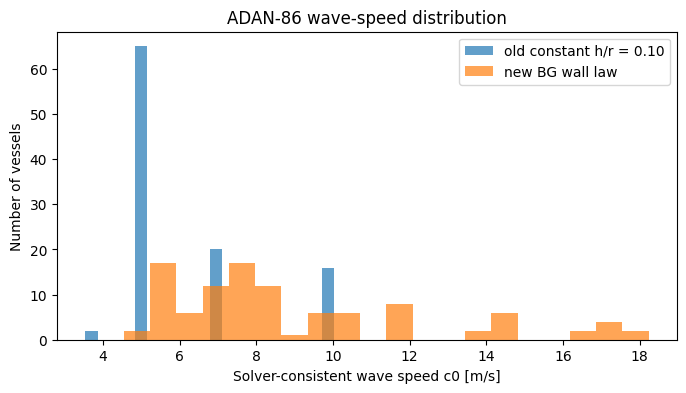

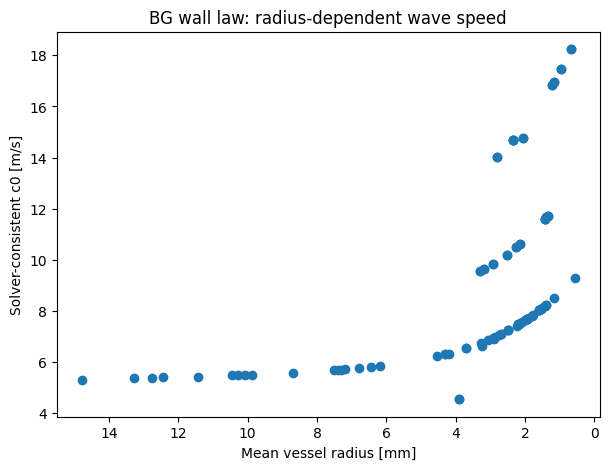

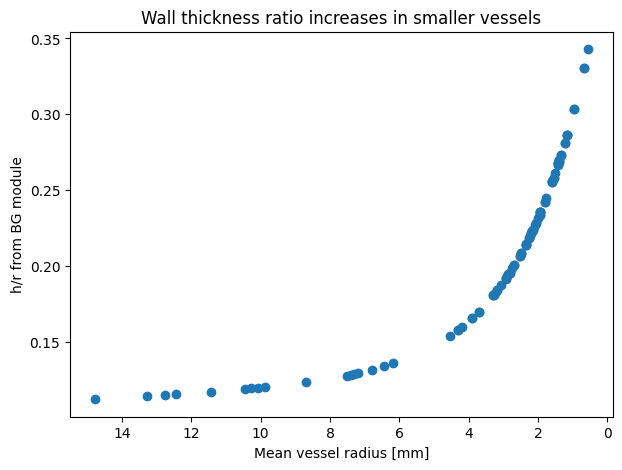

In [6]:

plt.figure(figsize=(8, 4))
plt.hist(c0_const_solver, bins=20, alpha=0.7, label="old constant h/r = 0.10")
plt.hist(c0_bg_solver, bins=20, alpha=0.7, label="new BG wall law")
plt.xlabel("Solver-consistent wave speed c0 [m/s]")
plt.ylabel("Number of vessels")
plt.title("ADAN-86 wave-speed distribution")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(node_full_df["radius_mean_m"] * 1000.0, node_full_df["c0_solver_m_per_s"])
plt.xlabel("Mean vessel radius [mm]")
plt.ylabel("Solver-consistent c0 [m/s]")
plt.title("BG wall law: radius-dependent wave speed")
plt.gca().invert_xaxis()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(node_full_df["radius_mean_m"] * 1000.0, node_full_df["h_over_r_bg"])
plt.xlabel("Mean vessel radius [mm]")
plt.ylabel("h/r from BG module")
plt.title("Wall thickness ratio increases in smaller vessels")
plt.gca().invert_xaxis()
plt.show()


## 7. Expose solver-ready variables

This cell mirrors the variable names used by your later solver notebooks.


In [7]:
order = adan_data["order"]

A0v = adan_data["A0v"]
Lv = adan_data["Lv"]
rv = adan_data["rv"]
r_proximal_v = adan_data["r_proximal_v"]
r_distal_v = adan_data["r_distal_v"]
hv = adan_data["hv"]
h_over_r_v = adan_data["h_over_r_v"]
Ev = adan_data["Ev"]
betav = adan_data["betav"]
c0v = adan_data["c0v"]
c0_mk_v = adan_data["c0_mk_v"]
c0_solver_v = adan_data["c0_solver_v"]
Z0v = adan_data["Z0v"]

dxv = adan_data["dxv"]
Nv = adan_data["Nv"]
dt_global = adan_data["dt_global"]

parent_idx = adan_data["parent_idx"]
children_idx = adan_data["children_idx"]
children_map_idx = adan_data["children_map_idx"]
terminal_idx = adan_data["terminal_idx"]
cellml_terminal_idx = adan_data["cellml_terminal_idx"]
root_idx = adan_data["root_idx"]

RHO = adan_data["RHO"]
MU = adan_data["MU"]
MMHG = adan_data["MMHG"]

print("Solver-ready arrays exposed.")
print(f"A0v shape:        {A0v.shape}")
print(f"betav shape:      {betav.shape}")
print(f"c0v range:        {c0v.min():.3f} - {c0v.max():.3f} m/s")
print(f"dt_global:        {dt_global:.8e} s")
print(f"terminal vessels: {len(terminal_idx)}")


Solver-ready arrays exposed.
A0v shape:        (103,)
betav shape:      (103,)
c0v range:        4.542 - 18.238 m/s
dt_global:        7.47174338e-05 s
terminal vessels: 43


## 8. Strong sanity checks

If this cell passes, the parsed data are safe to use downstream.


In [8]:
# Graph consistency.
assert len(order) == 103, f"Expected 103 vessels for ADAN-86, got {len(order)}"
assert len(topology_df) == len(order) - 1, "Tree must have V-1 edges"
assert len(root_idx) == 1, "Expected exactly one root"
assert node_full_df["is_root"].sum() == 1, "Expected exactly one root row"

# Terminal consistency.
assert np.array_equal(np.sort(terminal_idx), np.sort(cellml_terminal_idx)), (
    "Topological terminals do not match CellML v_T terminals"
)
assert len(terminal_idx) == 43, f"Expected 43 ADAN-86 terminals, got {len(terminal_idx)}"

# Physical values.
required_arrays = {
    "A0v": A0v,
    "Lv": Lv,
    "rv": rv,
    "hv": hv,
    "Ev": Ev,
    "betav": betav,
    "c0v": c0v,
    "Z0v": Z0v,
    "dxv": dxv,
}

for name, arr in required_arrays.items():
    arr = np.asarray(arr)
    assert np.all(np.isfinite(arr)), f"{name} has non-finite values"
    assert np.all(arr > 0), f"{name} has non-positive values"

# Wall-law checks.
assert np.min(h_over_r_v) > 0.10, "BG h/r should be above old constant 0.10 for this file"
assert len(np.unique(np.round(c0v, 3))) > 4, "BG parser should not collapse to only four wave-speed bands"

# CFL check.
cfl_actual = c0v * dt_global / dxv
assert np.max(cfl_actual) <= adan_data["CFL_TARGET"] + 1e-12, "CFL exceeded target"

print("All sanity checks passed.")
print(f"max CFL = {np.max(cfl_actual):.3f}")
print(f"unique rounded c0v = {len(np.unique(np.round(c0v, 3)))}")


All sanity checks passed.
max CFL = 0.400
unique rounded c0v = 68


## 9. Save parser outputs

Use `adan_parsed_bg.pkl` in later notebooks instead of the old `adan_parsed.pkl`.


In [9]:

node_full_df.to_csv("adan86_parsed_bg_from_cellml.csv", index=False)
topology_df[["parent", "child"]].to_csv("adan86_edges_bg_from_cellml.csv", index=False)
comparison_df.to_csv("adan86_wall_speed_comparison.csv", index=False)

save_adan_pickle(adan_data, "adan_parsed_bg.pkl")

print("Saved files:")
print("  adan_parsed_bg.pkl")
print("  adan86_parsed_bg_from_cellml.csv")
print("  adan86_edges_bg_from_cellml.csv")
print("  adan86_wall_speed_comparison.csv")


Saved: D:\code\adan_project\adan_parsed_bg.pkl
File size MB: 0.160
Saved files:
  adan_parsed_bg.pkl
  adan86_parsed_bg_from_cellml.csv
  adan86_edges_bg_from_cellml.csv
  adan86_wall_speed_comparison.csv


## 10. Reload test

This confirms that downstream notebooks can load the saved pickle cleanly.


In [10]:

loaded = load_adan_pickle("adan_parsed_bg.pkl")

assert loaded["diagnostics"]["n_vessels"] == 103
assert loaded["diagnostics"]["n_terminals_topology"] == 43
assert loaded["wall_model"] == "bg_modules_v2"
assert np.allclose(loaded["c0v"], adan_data["c0v"])
assert np.allclose(loaded["hv"], adan_data["hv"])

print("Reload test passed.")
print("Loaded keys:")
print(sorted(loaded.keys()))


Reload test passed.
Loaded keys:
['A0v', 'CFL_TARGET', 'C_bg_v', 'DX_TARGET', 'Ev', 'I_bg_v', 'Lv', 'MMHG', 'MU', 'Nv', 'RHO', 'R_bg_v', 'Rv_bg_v', 'Z0v', 'betav', 'bg_wall_constants_df', 'c0_mk_v', 'c0_solver_v', 'c0v', 'cellml_terminal_idx', 'children_idx', 'children_map_idx', 'diagnostics', 'dt_global', 'dxv', 'h_over_r_v', 'hv', 'module_df', 'node_full_df', 'order', 'params_df', 'parent_idx', 'q0_bg_v', 'r_distal_v', 'r_proximal_v', 'root_idx', 'rv', 'terminal_idx', 'topology_df', 'vessel_to_idx', 'wall_constants', 'wall_model']
